<a href="https://colab.research.google.com/github/Anzonfire/Machine-Learning/blob/main/expno%203/3_scenario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_160/3276090388.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.median(), inplace=True)


MSE: 208.27581979943199
RMSE: 14.431764264961924
R2 Score: 0.028412764928523737
Study_Hours                    0.101244
Attendance                    -0.480247
parental level of education   -0.993953
test preparation course       -3.829889
Sleep_Hours                   -0.277323
dtype: float64


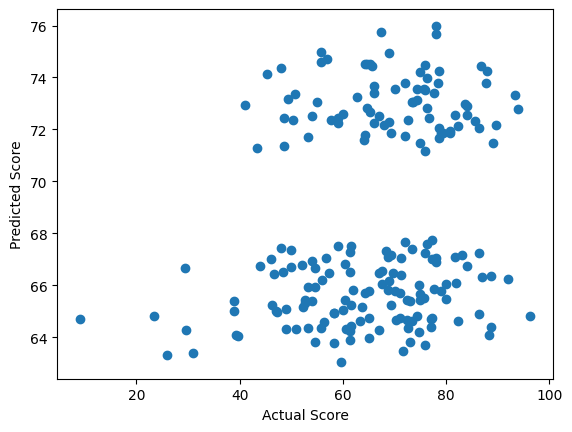

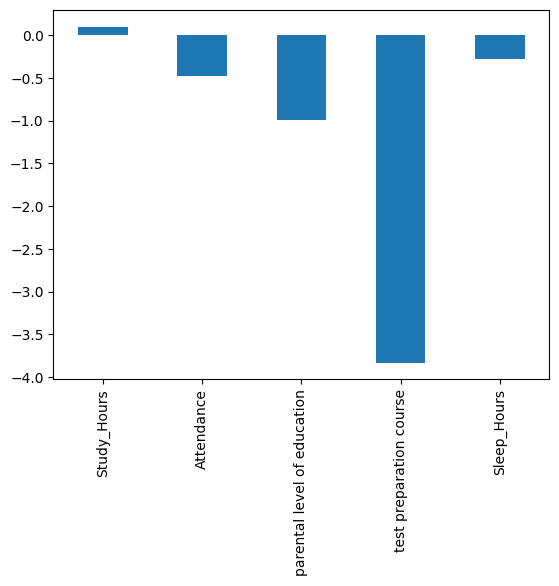

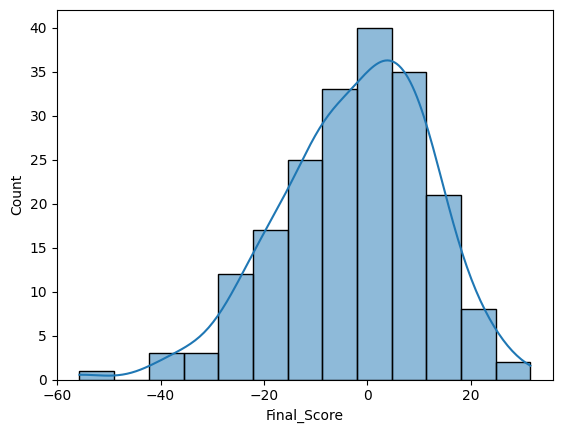

Ridge R2: 0.028441240433170867
Lasso R2: 0.02969953401384584


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("StudentsPerformance.csv")

df["Final_Score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df["parental level of education"] = df["parental level of education"].astype("category").cat.codes
df["test preparation course"] = df["test preparation course"].astype("category").cat.codes

df["Study_Hours"] = np.random.randint(1, 6, size=len(df))
df["Attendance"] = np.random.randint(60, 100, size=len(df))
df["Sleep_Hours"] = np.random.randint(5, 9, size=len(df))

features = [
    "Study_Hours",
    "Attendance",
    "parental level of education",
    "test preparation course",
    "Sleep_Hours"
]

X = df[features]
y = df["Final_Score"]

X.fillna(X.median(), inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

coefficients = pd.Series(model.coef_, index=features)
print(coefficients)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.show()

coefficients.plot(kind='bar')
plt.show()

residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.show()

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
print("Ridge R2:", r2_score(y_test, ridge_pred))

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
print("Lasso R2:", r2_score(y_test, lasso_pred))